In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import compoundx_figs as cxf
import warnings

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from cartopy import crs, feature

from compoundx_figs import vis

plt.style.use("./scripts/plotting.mplstyle")

In [3]:
data = cxf.Datasets.from_yaml("data/sources.yaml", with_cache=True)

In [4]:
ds_spatial_stats = xr.open_zarr("data/derived/spatial_stats.zarr")

# Figure 2

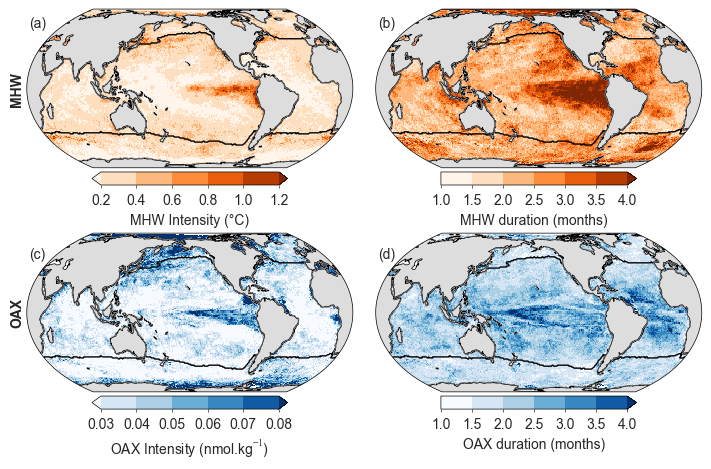

In [5]:
fig_top = plt.figure(figsize=[7.5, 5.1], dpi=100)

props_imshow = {
    "cbar_kwargs": {"orientation": "horizontal", "shrink": 0.6},
    "proj": crs.EqualEarth(-155),
}

img1 = ds_spatial_stats.mhw_I.geo.imshow(pos=221, **props_imshow, levels=np.arange(0.2, 1.3, 0.2))
img2 = ds_spatial_stats.mhw_D.geo.imshow(pos=222, **props_imshow, levels=np.arange(1, 4.1, 0.5))
img3 = ds_spatial_stats.oax_I.geo.imshow(pos=223, **props_imshow, levels=np.arange(0.03, 0.09, 0.01))
img4 = ds_spatial_stats.oax_D.geo.imshow(pos=224, **props_imshow, levels=np.arange(1, 4.1, 0.5))

[cxf.vis.plot_contours(data.masks.regions_HL, img.axes) for img in [img1, img2, img3, img4]]

if "collapse_labels":
    props_text = dict(rotation=90, weight="bold", ha="center", va="center", zorder=10)
    img1.axes.text(-0.03, 0.5, "MHW", transform=img1.axes.transAxes, **props_text)
    img3.axes.text(-0.03, 0.5, "OAX", transform=img3.axes.transAxes, **props_text)

    cxf.vis.number_subplots([img1.axes, img2.axes, img3.axes, img4.axes], space=0.02)

plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.1)

fig_top.savefig("./figures/figure2_top_w7.5.png", dpi=300, transparent=True)


In [6]:
mask_HL = (data.masks.regions_HL == 1) & data.masks.ice_mask
mask_LL = (data.masks.regions_HL == 2) & data.masks.ice_mask
area_HL_Mkm2 = (data.masks.area * mask_HL).sum().compute() / 1e12
area_LL_Mkm2 = (data.masks.area * mask_LL).sum().compute() / 1e12

def compute_area(da, mask):
    return data.masks.area.where(da.mask & mask).sum(["lat", "lon"]).compute().pipe(cxf.vis.line.smooth, w=12) / 1e12
mhw_HL_area = compute_area(data.mhw, mask_HL)
mhw_LL_area = compute_area(data.mhw, mask_LL)
oax_HL_area = compute_area(data.oax, mask_HL)
oax_LL_area = compute_area(data.oax, mask_LL)
# for Figure 3
cex_HL_area = compute_area(data.cex, mask_HL)
cex_LL_area = compute_area(data.cex, mask_LL)

def hl_pct_to_area(x): return (x / 100) * area_HL_Mkm2.values
def ll_pct_to_area(x): return (x / 100) * area_LL_Mkm2.values

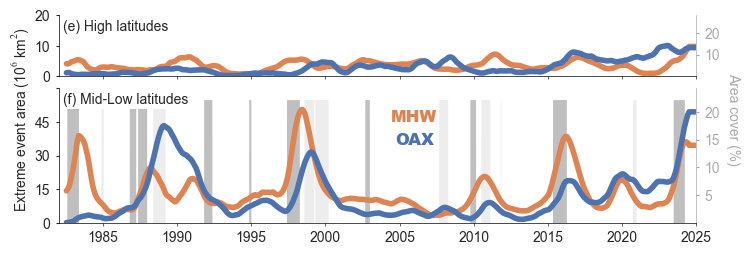

In [7]:
mosaic = "e\nf\nf"

fig_bot, axs = plt.subplot_mosaic(mosaic, figsize=(7.5, 2.5), sharex=True)
fig_bot.subplots_adjust(hspace=0.2, left=0.1, right=0.95, top=0.98, bottom=0.15)


with plt.rc_context({"lines.linewidth": 4}):
    mhw_HL_area.plot(ax=axs["e"], label="MHW", c="C1")
    oax_HL_area.plot(ax=axs["e"], label="OAX", c="C0")

    mhw_LL_area.plot(ax=axs["f"], label="MHW", c="C1")
    oax_LL_area.plot(ax=axs["f"], label="OAX", c="C0")

    x = data.masks.el_nino_mask.time
    bar_props = dict(lw=0, zorder=0)
    axs["f"].fill_between(x, data.masks.el_nino_mask * 55, color="0.75", **bar_props)
    axs["f"].fill_between(x, data.masks.la_nina_mask * 55, color="0.93", **bar_props)

if "collapse_secondary_axes_ticks":
    axs2 = {}

    axs2["e"] = vis.line.add_secondary_yaxis_with_custom_values(axs["e"], ticks=[10, 20], tick_inverter=hl_pct_to_area)
    axs2["f"] = vis.line.add_secondary_yaxis_with_custom_values(axs["f"], ticks=[5, 10, 15, 20], tick_inverter=ll_pct_to_area)

if "collapse_legend_labels":
    text_props = {"weight": 1000, "size": "large", "ha": "center", "family": "arial black"}
    text_x = pd.Timestamp("2006")
    axs["f"].text(text_x, 45, "MHW", c="C1", **text_props)
    axs["f"].text(text_x, 35, "OAX", c="C0", **text_props)

if "collapse_axes_ticks":
    axs["f"].set_xlim(pd.Timestamp("1982-01-01"), pd.Timestamp("2025-01-01"))  # type: ignore
    axs["e"].set_ylim(0, 20)
    axs["f"].set_ylim(0, 60)
    axs["f"].set_yticks([0, 15, 30, 45, 60])
    axs["f"].set_yticklabels(["0", "15", "30", "45", ""])
    axs["f"].set_xticks(pd.date_range("1985-01-01", "2025-01-01", freq="5YS"))
    axs["f"].set_xticklabels(np.arange(1985, 2026, 5))

if "collapse_axes_labels":

    vis.clear_labels(axs["e"])
    vis.clear_labels(axs["f"])

    vis.line.set_fig_ylabel(axs, "Extreme event area (10$^6$ km$^2$)", x=-0.05)
    vis.line.set_fig_ylabel(axs, "Area cover (%)", color="#aaaaaa", x=0.9)

    vis.number_subplots(
        axs.values(),
        ["(e) High latitudes", "(f) Mid-Low latitudes"],
        bbox=dict(facecolor="white", edgecolor="none", pad=2),
        space=0.04,
    )


fig_bot.savefig("./figures/figure2_bot_w7.5.pdf")
fig_bot.savefig("./figures/figure2_bot_w7.5.png", dpi=300, transparent=True)


# Figre 3

In [8]:
num_extremes = data.cex.mask.sum('time').compute()

num_extremes_seasonal = data.cex.mask.groupby("time.season").sum("time").compute()
num_extremes_smmmer_sh = num_extremes_seasonal.sel(season="DJF", lat=slice(-90, 0))
num_extremes_smmmer_nh = num_extremes_seasonal.sel(season="JJA", lat=slice(0, 90))
num_extremes_winter_sh = num_extremes_seasonal.sel(season="JJA", lat=slice(-90, 0))
num_extremes_winter_nh = num_extremes_seasonal.sel(season="DJF", lat=slice(0, 90))
num_extremes_summer = xr.concat([num_extremes_smmmer_sh, num_extremes_smmmer_nh], dim="lat", coords="all")
num_extremes_winter = xr.concat([num_extremes_winter_sh, num_extremes_winter_nh], dim="lat", coords="all")

quantile = 0.95
expected_num_compound_extremes = (1 - quantile)**2 * data.cex.time.size
num_years = np.unique(data.cex.time.dt.year).size

def make_cbar_secondary_xaxis(img):
    return img.colorbar.ax.secondary_xaxis("top").xaxis

def inverse_lmf(x):
    return x * expected_num_compound_extremes

def inverse_freq(x):
    return x * num_years

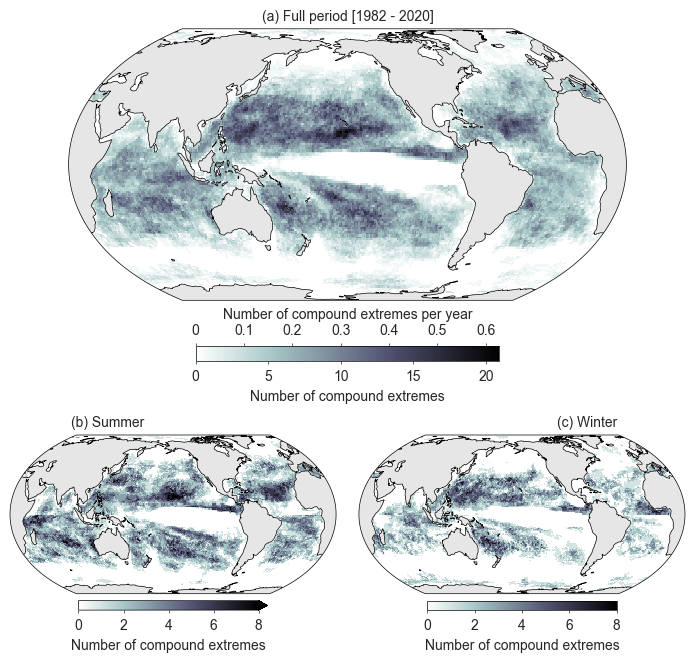

In [9]:
if "collapse_figure_layout":
    fig, axs = plt.subplot_mosaic(
        "aa\naa\naa\nbc\nbc",
        figsize=(7.5, 6.8),
        subplot_kw={"projection": crs.EqualEarth(central_longitude=205)},
    )

    fig.subplots_adjust(hspace=0.1)

if "collapse_plot_maps":
    props = {
        "transform": crs.PlateCarree(),
        "cmap": "bone_r",
        "cbar_kwargs":{
            "pad": 0.13,
            "fraction": 0.1,
            "location": "bottom",
            "aspect": 20,
            "shrink": 0.45,
            "extendfrac": 0.05,
            "label": "Number of compound extremes"}}

    img_top = num_extremes.plot.imshow(ax=axs["a"], **props)

    props["cbar_kwargs"] |= {"shrink": 0.58, "pad": 0.03}
    img_left  = num_extremes_summer.plot.imshow(ax=axs["b"], vmax=8, **props)
    img_right = num_extremes_winter.plot.imshow(ax=axs["c"], vmax=8, **props)

if "collapse_add_map_features":
    [ax.add_feature(feature.LAND, facecolor="0.9", zorder=2) for ax in axs.values()]
    [ax.coastlines(lw=0.5, color='k', zorder=3) for ax in axs.values()]

if "collapse_labels":
    [cxf.vis.clear_labels(ax) for ax in axs.values()]

    img_top.axes.set_title("(a) Full period [1982 - 2020]", size="medium")
    img_left.axes.set_title("(b) Summer", x=0.3, ha="center", size="medium")
    img_right.axes.set_title("(c) Winter", x=0.7, ha="center", size="medium")

if "collapse_colorbar_labels":
    expected_label = r"$\frac{\text{Number of compound extremes}}{\text{Expected number of compound extremes}}$"
    number_events = "Number of compound extremes"
    events_per_year = "Number of compound extremes per year"
    vis.line.custom_tick_values(
        axis=img_top.colorbar.ax.xaxis,
        ticks=[0, 5, 10, 15, 20],
        tick_inverter=inverse_lmf,
        label=number_events,
    )

    vis.line.custom_tick_values(
        make_cbar_secondary_xaxis(img_top),
        ticks=np.arange(0, 0.61, 0.1),
        tick_inverter=inverse_freq,
        label=events_per_year,
    )
    ...

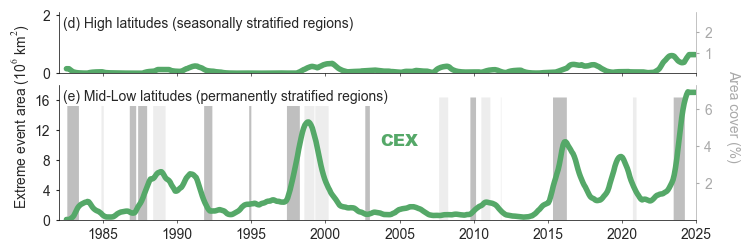

In [10]:
mosaic = "e\nf\nf"

fig_bot, axs = plt.subplot_mosaic(mosaic, figsize=(7.5, 2.5), sharex=True)
fig_bot.subplots_adjust(hspace=0.2, left=0.1, right=0.95, top=0.98, bottom=0.15)


with plt.rc_context({"lines.linewidth": 4}):
    cex_HL_area.plot(ax=axs["e"], label="CEX", c="C2")
    cex_LL_area.plot(ax=axs["f"], label="CEX", c="C2")

    x = data.masks.el_nino_mask.time
    bar_props = dict(lw=0, zorder=0)
    y1 = axs["f"].get_ylim()[1] * 0.95
    axs["f"].fill_between(x, data.masks.el_nino_mask * y1, color="0.75", **bar_props)
    axs["f"].fill_between(x, data.masks.la_nina_mask * y1, color="0.93", **bar_props)

if "collapse_secondary_axes_ticks":
    axs2 = {}
    axs2["e"] = vis.line.add_secondary_yaxis_with_custom_values(axs["e"], ticks=[1, 2], tick_inverter=hl_pct_to_area)
    axs2["f"] = vis.line.add_secondary_yaxis_with_custom_values(axs["f"], ticks=[2, 4, 6], tick_inverter=ll_pct_to_area)

if "collapse_legend_labels":
    text_props = {"weight": 1000, "size": "large", "ha": "center", "family": "arial black"}
    text_x = pd.Timestamp("2005")
    axs["f"].text(text_x, 10, "CEX", c="C2", **text_props)

if "collapse_axes_ticks":
    axs["f"].set_xlim(pd.Timestamp("1982-01-01"), pd.Timestamp("2025-01-01"))  # type: ignore
    axs["e"].set_ylim(0, 2.1)
    axs["f"].set_ylim(0, 18)
    axs["f"].set_yticks([0, 4, 8, 12, 16])
    axs["f"].set_xticks(pd.date_range("1985-01-01", "2025-01-01", freq="5YS"))
    axs["f"].set_xticklabels(np.arange(1985, 2026, 5))

if "collapse_axes_labels":
    vis.clear_labels(axs["e"])
    vis.clear_labels(axs["f"])

    vis.line.set_fig_ylabel(axs, "Extreme event area (10$^6$ km$^2$)", x=-0.05)
    vis.line.set_fig_ylabel(axs, "Area cover (%)", color="#aaaaaa", x=0.9)

    vis.number_subplots(
        axs.values(),
        [
            "(d) High latitudes (seasonally stratified regions)",
            "(e) Mid-Low latitudes (permanently stratified regions)",
        ],
        bbox=dict(facecolor="white", edgecolor="none", pad=2),
        space=0.04,
    )


# fig_bot.savefig("./figures/figure2_bot_w7.5.pdf")
# fig_bot.savefig("./figures/figure2_bot_w7.5.png", dpi=300, transparent=True)


# Figure 5

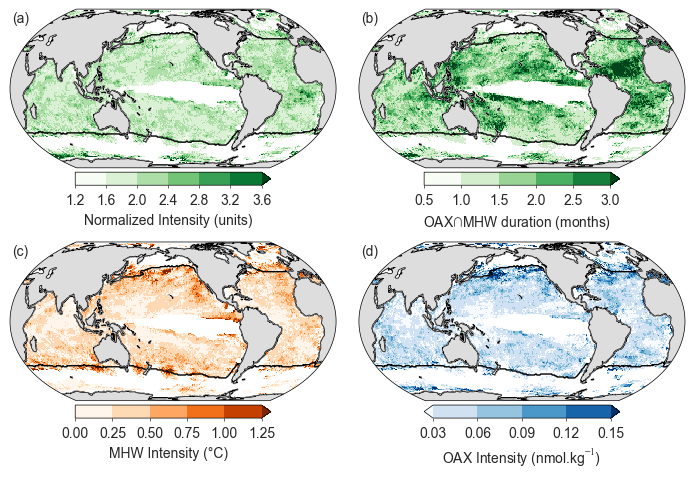

In [11]:
fig_top = plt.figure(figsize=[7.5, 5.3], dpi=100)
fig_top.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.1)


props_imshow = {
    "cbar_kwargs": {"orientation": "horizontal", "shrink": 0.6},
    "proj": crs.EqualEarth(-155),
}
imgs = [
    ds_spatial_stats.cex_I.geo.imshow(pos=221, levels=6, **props_imshow),
    ds_spatial_stats.cex_D.geo.imshow(pos=222, levels=np.arange(0.5, 3.1, 0.5), vmin=0.5, **props_imshow),
    ds_spatial_stats.cex_mhw_I.geo.imshow(pos=223, levels=6, **props_imshow),
    ds_spatial_stats.cex_oax_I.geo.imshow(pos=224, levels=np.arange(0.03, 0.18, 0.03), **props_imshow),
]

[cxf.vis.plot_contours(data.masks.regions_HL, img.axes) for img in imgs]

if "collapse_labels":
    cxf.vis.number_subplots([img.axes for img in imgs], space=0.02)


# fig_top.savefig("./figures/figure2_top_w7.5.png", dpi=300, transparent=True)

# Figure 6

In [12]:
chosen_events = [
    dict(idx=24, text="Madagascar\n(1987)", dx=0.3, dy=0.45, ha="center"),
    dict(idx=231, text="Mediterranean\nSea (2003)", dx=-0.4, dy=0.7, ha="center"),
    dict(idx=294, text="Western\nAustralia\n(2011)", dx=0, dy=0.6, ha="left"),
    dict(idx=330, text="The Blob (2015)", dx=-0, dy=1, ha="center"),
    dict(idx=352, text="South Pacific\n(2015)", dx=0.3, dy=-0.8, ha="center"),
    dict(idx=437, text="Barrier Reef\n(2022)", dx=-0.3, dy=-0.45, ha="center"),
    dict(idx=450, text="Atlantic\n(2023)", dx=-0.2, dy=1.0, ha="center"),
    # dict(idx=154, text="Northern \nEq. Pacific \n(1998)", dx=0.1, dy=0.5, ha="center"),
    # dict(idx=159, text="SE Asia\n(1998)", dx=0.2, dy=-0.5),
    # dict(idx=449, text="Indian Ocean\n(2023)", dx=0.3, dy=0.75, ha='left'),
    # dict(idx=463, text="Blob 2 (2019)", dx=0, dy=+0.5, ha="center"),
    # dict(idx=484, text="Kuriosho\nCurrent (2024)", dx=-0.7, dy=0.9, ha="right"),
]
event_idxs = [v["idx"] for v in chosen_events]

In [13]:
df = data.cex["stats"].to_series().unstack()
df["duration_2sigma_mon_clipped"] = df["duration_2sigma_mon"].where(
    lambda x: x < df.duration_max_mon, df.duration_max_mon
)
df["area_max_mil"] = df.area_max_km2 * 1e-6
df["area_max_scl"] = (df.area_max_mil - df.area_max_mil.min() + 2.3) ** 2.6

df["chosen"] = False
df["chose_description"] = ""
df.loc[event_idxs, "chosen"] = True
df["cex_intensity_norm_p95"] = df.cex_intensity_norm_p95.clip(0, 10)

In [14]:
most_extreme = data.cex.blobs.isin(event_idxs).compute()
most_intense_avg = data.cex.intensity_norm.where(most_extreme & data.cex.mask).quantile(0.95, dim="time")
most_extreme_contours = most_extreme.any("time").astype(int)

In [15]:
def plot_extreme_events_scatter(
    df,
    ax: plt.Axes,
    x="duration_avg_mon",
    y="cex_intensity_norm_p95",
    c="area_max_km2",
    s="area_max_km2",
    cmap="cividis_r",
    highlight_index=None,
    n_colors=10,
    **kwargs,
):

    cmap = plt.cm.get_cmap(cmap, n_colors)
    props = {
        "x": x,
        "y": y,
        "c": c,
        "s": s,
        "cmap": cmap,
        "vmin": 0,
        "vmax": cmap.N,
        "edgecolor": "k",
        "linewidth": 0.3,
        "colorbar": False,
    } | kwargs

    df_sorted = df.sort_values(props["c"], ascending=False)
    df_sorted.plot.scatter(ax=ax, **props)

    if highlight_index is not None:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning, message=".*colormapping.*")
            
            df_sorted_highlighted = df_sorted.loc[highlight_index]

            props.update(linewidth=4, zorder=5, c="none", edgecolor="w")
            df_sorted_highlighted.plot.scatter(ax=ax, **props)
            
            props.update(linewidth=1.5, zorder=5, c="none", edgecolor="k")
            df_sorted_highlighted.plot.scatter(ax=ax, **props)


    vis.scatter_extras.buffer_axis_limits(ax)


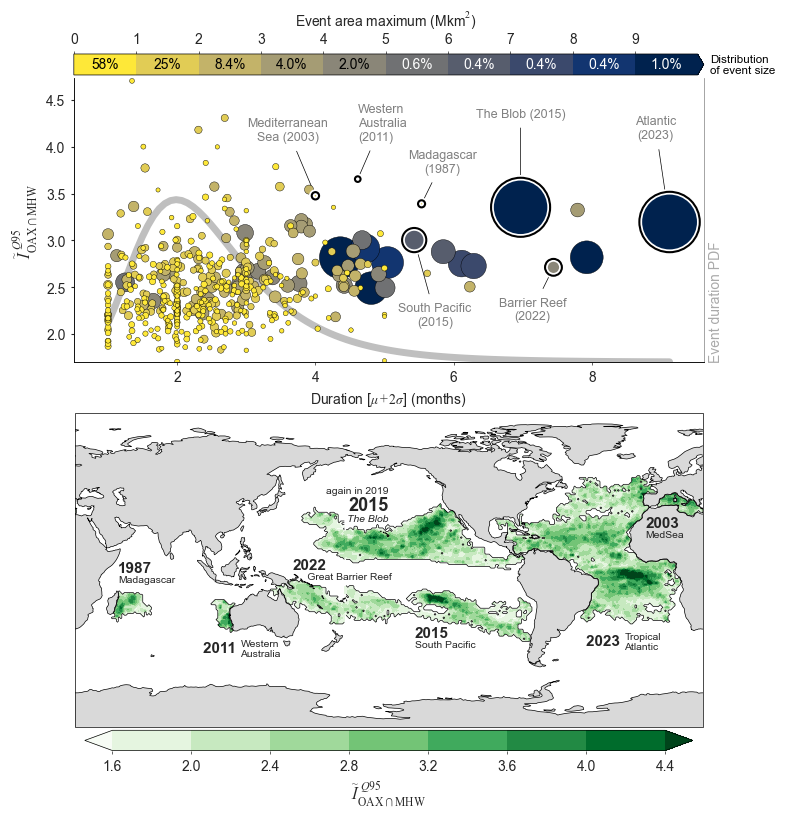

In [ ]:
if "collapse_figure_layout":
    fig = plt.figure(figsize=(7, 8.3))
    axs: list[plt.Axes] = [
        fig.add_subplot(211),
        fig.add_subplot(212, projection=crs.PlateCarree(205)),
    ]

    fig.subplots_adjust(hspace=0.15)

if 1:  # collapse_scatter_plotting
    if "collapse_plot_scatter":
        plot_extreme_events_scatter(
            df,
            c="area_max_mil",
            s="area_max_scl",
            x="duration_2sigma_mon_clipped",
            y="cex_intensity_norm_p95",
            highlight_index=event_idxs,
            cmap="cividis_r",
            ax=axs[0],
        )

    if "collapse_scatter_annotations":

        def plot_arrow(idx, text, dx, dy, **kwargs):
            y, x = df.loc[idx, ["cex_intensity_norm_p95", "duration_2sigma_mon_clipped"]]
            ty = y + dy
            tx = x + dx
            props = dict(
                size=9,
                va="center",
                ha="left",
                color="grey",
                zorder=0,
                arrowprops=dict(arrowstyle="-", lw=0.5, color="k"),
                bbox={"facecolor": "white", "alpha": 0.6, "lw": 0},
            )
            props.update(kwargs)
            axs[0].annotate(text, xy=(x, y), xytext=(tx, ty), **props)

        for arrow in chosen_events:
            plot_arrow(**arrow)

    if "collapse_plot_additional_features":
        ax2 = vis.scatter_extras.scatter_x_distribution(axs[0])

        cb = vis.scatter_extras.scatter_colorbar_distribution(axs[0])
        cb.set_label("Event area maximum (Mkm$^2$)")
        cb.set_secondary_label("Distribution\nof event size", size='small')
        
    if "collapse_scatter_labelling":
        compound_intensity_q95 = r"$\widetilde{\mathit{I}}^{\ Q95}_{\rm{OAX}\cap\rm{MHW}}$"
        axs[0].set_ylabel(compound_intensity_q95, size=12)
        axs[0].set_xlabel(r"Duration [$\mu + 2\sigma$] (months)")
        ax2.set_ylabel("Event duration PDF", color="#aaaaaa", va='top', loc='bottom')

    if "collapse_scatter_axes_ticks":
        axs[0].set_ylim(1.7, 4.73)
        ax2.set_ylim(0, 0.8)
        ax2.set_yticks([])

if 1:  # collapse_map_plotting
    if "collapse_plot_map":

        axs[1].coastlines(resolution="110m", color="k", lw=0.5, zorder=3)
        axs[1].add_feature(feature.LAND.with_scale("110m"), facecolor="0.85", zorder=2)

        da = cxf.vis.fill_lon_gap(most_intense_avg)
        img = da.plot.contourf(
            ax=axs[1],
            transform=crs.PlateCarree(),
            levels=np.arange(1.6, 4.7, 0.4),
            cmap="Greens",
            cbar_kwargs=dict(orientation="horizontal", shrink=1, aspect=30, fraction=0.06, pad=0.01),
        )

    if "collapse_map_contours":
        img.axes.contour(
            most_extreme_contours.lon,
            most_extreme_contours.lat,
            most_extreme_contours,
            transform=crs.PlateCarree(),
            levels=[0.5, 1.5],
            colors=["k"],
            linewidths=[0.5],
        )

        img.axes.set_title("")
        label_compound_intensity = r"$\widetilde{\mathit{I}}^{\ Q95}_{\rm{OAX}\cap\rm{MHW}}$"
        img.colorbar.set_label(label_compound_intensity, size=12)

    if "collapse_map_annotations": 
        bf = dict(size=11, weight="bold", va="bottom", zorder=7)
        sf = dict(size=7.5, va="top", zorder=7)

        props = dict(ha="right", transform=crs.PlateCarree())
        axs[1].text(-155, 44, "again in 2019", size=sf["size"], **props)
        axs[1].text(-155, 34, "2015", size=13, weight="bold", **props)
        axs[1].text(-155, 32, "The Blob", style="italic", **sf, **props)

        props = dict(ha="left", transform=crs.PlateCarree())
        axs[1].text(150, -1, "2022", **bf, **props)
        axs[1].text(150, -1, "     Great Barrier Reef", **sf, **props)

        props = dict(transform=crs.PlateCarree())
        axs[1].text(-140, -40, "2015", ha="left", **bf, **props)
        axs[1].text(-140, -40, "South Pacific", ha="left", **(sf), **props)

        props = dict(transform=crs.PlateCarree())
        axs[1].text(50, -3, "1987", **bf, **props)
        axs[1].text(50, -3, "Madagascar", **sf, **props)
        
        props = dict(transform=crs.PlateCarree(), va="center")
        axs[1].text(-20, -41, "2023 ", **(bf | props | dict(ha="right")))
        axs[1].text(-20, -41, "Tropical\nAtlantic", **(sf | props | dict(ha="left")))

        props = dict(transform=crs.PlateCarree(), va="center")
        axs[1].text(120, -45, "2011 ", **(bf | props | dict(ha="right")))
        axs[1].text(120, -45, "Western\nAustralia", **(sf | props | dict(ha="left")))

        props = dict(transform=crs.PlateCarree())
        axs[1].text(-8, 23, "2003", **bf, **props)
        axs[1].text(-8, 23, "MedSea", **sf, **props)

    if "collapse_map_extent":
        axs[1].set_extent([-180, 180, -90, 90], crs=crs.PlateCarree())

fig.savefig("./figures/fig6_bot_only-with_annotations_top.pdf", bbox_inches="tight")